# Illiquid Equity Model

Описание прототипа модели: https://docs.google.com/document/d/12-7goJSQMmdUkTSbKAXRC9kTlNrC-rXoqVaEl47YyPY/edit?usp=sharing

## 1. УСТАНОВКА ЗАВИСИМОСТЕЙ

In [1]:
%%capture
!pip install arch # matplotlib seaborn pyyaml scipy statsmodels pandas numpy -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime, timedelta
from scipy.linalg import cholesky
from scipy.optimize import minimize
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## 2. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ С НЕЛИКВИДНЫМИ АКЦИЯМИ

In [3]:
# Параметры
N_LIQUID = 30
N_ILLIQUID = 5
N_ASSETS = N_LIQUID + N_ILLIQUID
N_DAYS = 750
N_PATHS = 1000
HORIZON = 252

# Ликвидность по акциям
liquidity_ratios = {}
tickers = []

for i in range(N_LIQUID):
    ticker = f'LIQ_{i:03d}'
    tickers.append(ticker)
    liquidity_ratios[ticker] = np.random.uniform(0.85, 1.0)

for i in range(N_ILLIQUID):
    ticker = f'ILL_{i:03d}'
    tickers.append(ticker)
    liquidity_ratios[ticker] = np.random.uniform(0.30, 0.79)

print(f"Ликвидные: {N_LIQUID}, Неликвидные: {N_ILLIQUID}")

# Даты
start_date = datetime(2023, 1, 1)
dates = pd.date_range(start_date, periods=N_DAYS, freq='B')

# Генерация режимов
regime = np.zeros(N_DAYS, dtype=int)
regime[:200] = 1
for i in range(200, N_DAYS):
    if regime[i-1] == 1:
        regime[i] = 0 if np.random.random() < 0.02 else 1
    else:
        regime[i] = 1 if np.random.random() < 0.05 else 0

bull_mask = regime == 1
bear_mask = regime == 0

print(f"Bull дней: {bull_mask.sum()}, Bear дней: {bear_mask.sum()}")

# Калибровка вероятностей перехода
def calculate_transition_probs(regime_array):
    transitions = {'bull_to_bear': 0, 'bull_stay': 0, 'bear_to_bull': 0, 'bear_stay': 0}
    for i in range(1, len(regime_array)):
        if regime_array[i-1] == 1:
            if regime_array[i] == 0:
                transitions['bull_to_bear'] += 1
            else:
                transitions['bull_stay'] += 1
        else:
            if regime_array[i] == 1:
                transitions['bear_to_bull'] += 1
            else:
                transitions['bear_stay'] += 1

    p_bull_to_bear = transitions['bull_to_bear'] / max(1, transitions['bull_to_bear'] + transitions['bull_stay'])
    p_bear_to_bull = transitions['bear_to_bull'] / max(1, transitions['bear_to_bull'] + transitions['bear_stay'])
    return p_bull_to_bear, p_bear_to_bull

P_BULL_TO_BEAR, P_BEAR_TO_BULL = calculate_transition_probs(regime)
print(f"P(Bull→Bear): {P_BULL_TO_BEAR:.4f}")
print(f"P(Bear→Bull): {P_BEAR_TO_BULL:.4f}")

# Рыночные доходности с GARCH
market_returns = np.zeros(N_DAYS)
market_volatility = np.zeros(N_DAYS)
market_volatility[0] = 0.01
market_returns[0] = np.random.normal(0.0005, market_volatility[0])

GARCH_PARAMS = {
    'bull': {'omega': 0.00001, 'alpha': 0.10, 'beta': 0.85, 'drift': 0.0005},
    'bear': {'omega': 0.00005, 'alpha': 0.15, 'beta': 0.80, 'drift': -0.0010}
}

for i in range(1, N_DAYS):
    params = GARCH_PARAMS['bull'] if regime[i] == 1 else GARCH_PARAMS['bear']
    market_volatility[i] = np.sqrt(
        params['omega'] +
        params['alpha'] * market_returns[i-1]**2 +
        params['beta'] * market_volatility[i-1]**2
    )
    market_returns[i] = params['drift'] + np.random.normal(0, market_volatility[i])

# Сектора
sectors = {
    'Banks': tickers[:5],
    'OilGas': tickers[5:10],
    'Tech': tickers[10:15],
    'Retail': tickers[15:18],
    'Utilities': tickers[18:]
}

# Генерация доходностей с индивидуальными дрейфами
asset_returns = pd.DataFrame(index=dates, columns=tickers, dtype=float)
asset_returns_raw = pd.DataFrame(index=dates, columns=tickers, dtype=float)

stock_drifts = {}
for ticker in tickers:
    if ticker.startswith('LIQ'):
        stock_drifts[ticker] = np.random.uniform(0.0003, 0.0008)
    else:
        stock_drifts[ticker] = np.random.uniform(0.0002, 0.0006)

for ticker in tickers:
    sector = None
    for sname, stickers in sectors.items():
        if ticker in stickers:
            sector = sname
            break

    if ticker.startswith('LIQ'):
        beta_bull, beta_bear = 1.30, 1.60
        sigma_idio = 0.010
    else:
        beta_bull, beta_bear = 1.50, 1.80
        sigma_idio = 0.020

    returns_raw = np.zeros(N_DAYS)
    for i in range(N_DAYS):
        beta = beta_bull if regime[i] == 1 else beta_bear
        market_component = beta * market_returns[i]
        idio_component = np.random.normal(0, sigma_idio)
        returns_raw[i] = stock_drifts[ticker] + market_component + idio_component

    asset_returns_raw[ticker] = returns_raw

    if ticker.startswith('ILL'):
        liq_ratio = liquidity_ratios[ticker]
        n_missing = int(N_DAYS * (1 - liq_ratio))
        missing_indices = np.random.choice(N_DAYS, n_missing, replace=False)
        returns_with_gaps = returns_raw.copy()
        returns_with_gaps[missing_indices] = np.nan
        asset_returns[ticker] = returns_with_gaps
    else:
        asset_returns[ticker] = returns_raw

prices = 100 * np.exp(asset_returns.fillna(0).cumsum())
print(f"Сгенерировано {N_ASSETS} акций с индивидуальными дрейфами")

Ликвидные: 30, Неликвидные: 5
Bull дней: 572, Bear дней: 178
P(Bull→Bear): 0.0175
P(Bear→Bull): 0.0562
Сгенерировано 35 акций с индивидуальными дрейфами


## 3. ФИЛЬТРАЦИЯ: ЛИКВИДНЫЕ VS НЕЛИКВИДНЫЕ

In [4]:
liquidity_threshold = 0.8
trading_days = (asset_returns.notna()).sum() / N_DAYS

liquid_tickers = [t for t in tickers if trading_days[t] >= liquidity_threshold]
illiquid_tickers = [t for t in tickers if trading_days[t] < liquidity_threshold]

print(f"Ликвидные: {len(liquid_tickers)}, Неликвидные: {len(illiquid_tickers)}")

Ликвидные: 30, Неликвидные: 5


## 4. ИМПУТАЦИЯ ПРОПУСКОВ (MARKET MODEL)

In [5]:
def impute_illiquid_returns(returns_df, market_returns, threshold=0.80):
    """Импутация пропусков через рыночную модель: R_illiquid = Beta × R_market"""
    returns_imputed = returns_df.copy()
    imputation_stats = {}

    for ticker in returns_df.columns:
        trading_ratio = returns_df[ticker].notna().sum() / len(returns_df)
        missing_mask = ~returns_df[ticker].notna()
        n_missing = missing_mask.sum()

        imputation_stats[ticker] = {
            'trading_ratio': trading_ratio,
            'n_missing': n_missing,
            'imputed': False,
            'beta': None
        }

        if trading_ratio < threshold and n_missing > 0:
            available_mask = returns_df[ticker].notna()
            if available_mask.sum() > 50:
                y = returns_df[ticker][available_mask].values
                x = market_returns[available_mask]
                try:
                    beta = np.cov(x, y, ddof=1)[0, 1] / np.var(x, ddof=1)
                    beta = np.clip(beta, 0.5, 3.0)
                except:
                    beta = 1.0
            else:
                beta = 1.0

            returns_imputed.loc[missing_mask, ticker] = beta * market_returns[missing_mask]
            imputation_stats[ticker]['imputed'] = True
            imputation_stats[ticker]['beta'] = beta

    return returns_imputed, imputation_stats

asset_returns_filled, imputation_stats = impute_illiquid_returns(
    asset_returns, market_returns, threshold=liquidity_threshold
)

imputed_count = sum(1 for s in imputation_stats.values() if s['imputed'])
print(f"Импутация: {imputed_count} акций")


Импутация: 5 акций


## 5. ФУНДАМЕНТАЛЬНАЯ КЛАСТЕРИЗАЦИЯ + КАЛИБРОВАННЫЕ КОРРЕЛЯЦИИ

In [6]:
illiquid_clusters = {}
for ticker in illiquid_tickers:
    for sname, stickers in sectors.items():
        if ticker in stickers:
            illiquid_clusters[ticker] = sname
            break

# Устойчивая калибровка корреляций с проверкой минимального размера выборки
MIN_SECTOR_SIZE = 3  # Минимум ликвидных акций в секторе для надёжной калибровки

sector_correlations = {}
sector_volatilities_bull = {}
sector_volatilities_bear = {}

for sector in set(illiquid_clusters.values()):
    sector_liquid = [t for t in liquid_tickers if t in sectors.get(sector, [])]

    if len(sector_liquid) >= MIN_SECTOR_SIZE:
        # Корреляция из ликвидных акций сектора
        sector_corr = asset_returns_filled[sector_liquid].corr().values
        sector_corr = sector_corr[np.triu_indices(len(sector_liquid), k=1)].mean()
        sector_correlations[sector] = sector_corr

        # Режим-зависимая волатильность из ликвидных акций сектора
        sector_volatilities_bull[sector] = asset_returns_filled[sector_liquid][bull_mask].std().mean()
        sector_volatilities_bear[sector] = asset_returns_filled[sector_liquid][bear_mask].std().mean()
    else:
        # Fallback при малом количестве ликвидных представителей
        sector_correlations[sector] = 0.70
        sector_volatilities_bull[sector] = asset_returns_filled[liquid_tickers][bull_mask].std().mean()
        sector_volatilities_bear[sector] = asset_returns_filled[liquid_tickers][bear_mask].std().mean()
        print(f"Сектор {sector}: недостаточно ликвидных акций ({len(sector_liquid)} < {MIN_SECTOR_SIZE}), используем fallback")

# Устойчивая калибровка межсекторных корреляций
inter_sector_correlations = {}
sectors_list = list(set(illiquid_clusters.values()))
for i, s1 in enumerate(sectors_list):
    for s2 in sectors_list[i+1:]:
        liquid_s1 = [t for t in liquid_tickers if t in sectors.get(s1, [])]
        liquid_s2 = [t for t in liquid_tickers if t in sectors.get(s2, [])]

        # Проверка минимального размера для устойчивой калибровки
        if len(liquid_s1) >= MIN_SECTOR_SIZE and len(liquid_s2) >= MIN_SECTOR_SIZE:
            cross_corr = asset_returns_filled[liquid_s1 + liquid_s2].corr().values
            n1 = len(liquid_s1)
            inter_sector = cross_corr[:n1, n1:].mean()
            inter_sector_correlations[(s1, s2)] = inter_sector
            inter_sector_correlations[(s2, s1)] = inter_sector
        else:
            # ← Fallback при недостатке данных
            inter_sector_correlations[(s1, s2)] = 0.50
            inter_sector_correlations[(s2, s1)] = 0.50
            print(f"Межсекторная корреляция {s1}-{s2}: недостаточно данных, используем fallback 0.50")

# Калибровка liquid-illiquid корреляций
liquid_illiquid_corr = asset_returns_filled[liquid_tickers + illiquid_tickers].corr().values
n_liquid = len(liquid_tickers)
liquid_illiquid_avg = liquid_illiquid_corr[:n_liquid, n_liquid:].mean()
print(f"Средняя корреляция Liquid-Illiquid: {liquid_illiquid_avg:.4f}")

# Ограничим liquid-illiquid корреляцию: максимум 0.75
liquid_illiquid_avg = min(liquid_illiquid_avg, 0.75)
print(f"Средняя корреляция Liquid-Illiquid: {liquid_illiquid_avg:.4f} (ограничено до 0.75)")

Средняя корреляция Liquid-Illiquid: 0.8509
Средняя корреляция Liquid-Illiquid: 0.7500 (ограничено до 0.75)


## 6. GARCH КАЛИБРОВКА ПО РЕЖИМАМ (BULL + BEAR) + ДЛЯ НЕЛИКВИДНЫХ

In [7]:
# Консервативный fallback при несходимости GARCH
def fit_garch_full(returns_series, min_obs=30):
    if len(returns_series) < min_obs:
        return None

    try:
        model = arch_model(returns_series, vol='GARCH', p=1, q=1,
                          mean='Zero', rescale=True, disp='off',
                          tol=1e-4)  # ← Более расслабленная tolerance
        result = model.fit(update_freq=0, show_warning=False)

        omega = result.params.get('omega', 0.00001)
        alpha = result.params.get('alpha[1]', 0.10)
        beta = result.params.get('beta[1]', 0.85)

        if (1 - alpha - beta) > 0:
            sigma_long_term = np.sqrt(omega / (1 - alpha - beta))
        else:
            sigma_long_term = returns_series.std()

        return {
            'omega': float(omega),
            'alpha': float(alpha),
            'beta': float(beta),
            'sigma_long_term': float(sigma_long_term),
            'converged': True
        }
    except:
        # Консервативный fallback: std + 10%
        return {
            'omega': 0.00001,
            'alpha': 0.10,
            'beta': 0.85,
            'sigma_long_term': float(returns_series.std() * 1.1),  # ← +10% консерватизм
            'converged': False
        }

# GARCH на ВСЕХ данных + по режимам отдельно
garch_all = {}
garch_bull = {}
garch_bear = {}

for ticker in liquid_tickers:
    garch_all[ticker] = fit_garch_full(asset_returns_filled[ticker], min_obs=100)
    garch_bull[ticker] = fit_garch_full(asset_returns_filled[ticker][bull_mask], min_obs=50)
    garch_bear[ticker] = fit_garch_full(asset_returns_filled[ticker][bear_mask], min_obs=50)

# Режим-зависимая волатильность для неликвидных (из сектора)
def get_liquidity_multiplier(trading_ratio):
    if trading_ratio >= 0.80:
        return 1.0
    elif trading_ratio >= 0.60:
        return 1.2
    elif trading_ratio >= 0.40:
        return 1.5
    else:
        return 2.0

liquidity_multipliers = {}
for ticker in tickers:
    liquidity_multipliers[ticker] = get_liquidity_multiplier(trading_days[ticker])

garch_illiquid = {}
for ticker in illiquid_tickers:
    sector = illiquid_clusters.get(ticker, 'Unknown')
    sigma_raw = asset_returns_filled[ticker].std()
    sigma_adjusted = sigma_raw * liquidity_multipliers[ticker]

    # Режим-зависимая волатильность из ликвидных акций сектора
    sigma_bull = sector_volatilities_bull.get(sector, sigma_adjusted) * liquidity_multipliers[ticker]
    sigma_bear = sector_volatilities_bear.get(sector, sigma_adjusted * 1.5) * liquidity_multipliers[ticker]

    garch_illiquid[ticker] = {
        'sigma_long_term': float(sigma_adjusted),
        'sigma_bull': float(sigma_bull),
        'sigma_bear': float(sigma_bear),
        'liquidity_multiplier': liquidity_multipliers[ticker],
        'sector': sector,
        'converged': False
    }

print(f"GARCH сходимость (All): {sum(1 for g in garch_all.values() if g and g['converged'])}/{len(liquid_tickers)}")
print(f"GARCH сходимость (Bull): {sum(1 for g in garch_bull.values() if g and g['converged'])}/{len(liquid_tickers)}")
print(f"GARCH сходимость (Bear): {sum(1 for g in garch_bear.values() if g and g['converged'])}/{len(liquid_tickers)}")

GARCH сходимость (All): 0/30
GARCH сходимость (Bull): 0/30
GARCH сходимость (Bear): 0/30


Для синтетических данных GARCH часто не сходится.
Для Production используем реальные исторические данные и более расслабленные параметры (tol=1e-4, maxiter=500).

## 7. ИНДИВИДУАЛЬНЫЕ ЛИКВИДНЫЕ ГОРИЗОНТЫ ПО АКЦИЯМ

In [8]:
# Индивидуальный liquidity horizon
def calculate_liquidity_horizon(trading_ratio, base_horizon=10):
    """
    Расчёт индивидуального liquidity horizon на основе ликвидности.

    Обоснование:
    - Чем ниже ликвидность, тем больше дней нужно для ликвидации позиции
    - Базовый горизонт 10 дней для ликвидных акций (80%+ дней торгов)
    - Для неликвидных масштабируется обратно пропорционально trading_ratio

    Формула: horizon = base_horizon × (0.80 / trading_ratio)
    """
    if trading_ratio >= 0.80:
        return base_horizon  # 10 дней для ликвидных
    else:
        # Масштабирование для неликвидных
        horizon = int(np.ceil(base_horizon * (0.80 / trading_ratio)))
        return min(horizon, 60)  # Максимум 60 дней (3 месяца)

liquidity_horizons = {}
for ticker in tickers:
    liquidity_horizons[ticker] = calculate_liquidity_horizon(trading_days[ticker])

print("   Liquidity Horizons по акциям:")
for ticker in illiquid_tickers:
    print(f"      {ticker}: {liquidity_horizons[ticker]} дней (ликвидность {trading_days[ticker]:.1%})")

# Портфельный weighted average liquidity horizon
portfolio_liquidity_horizon = np.mean([liquidity_horizons[t] for t in tickers])
print(f"\n   Средний liquidity horizon портфеля: {portfolio_liquidity_horizon:.1f} дней")

   Liquidity Horizons по акциям:
      ILL_000: 17 дней (ликвидность 48.0%)
      ILL_001: 12 дней (ликвидность 71.9%)
      ILL_002: 20 дней (ликвидность 40.0%)
      ILL_003: 19 дней (ликвидность 42.8%)
      ILL_004: 22 дней (ликвидность 37.9%)

   Средний liquidity horizon портфеля: 11.1 дней


## 8. ПОДГОТОВКА ПАРАМЕТРОВ ДЛЯ СИМУЛЯЦИИ

In [9]:
sim_params = {
    'liquid': {},
    'illiquid': {},
    'market': {
        'sigma_bull': market_returns[bull_mask].std(),
        'sigma_bear': market_returns[bear_mask].std(),
        'mu_bull': asset_returns_filled[bull_mask].mean().mean(),
        'mu_bear': asset_returns_filled[bear_mask].mean().mean(),
        'p_bull_to_bear': P_BULL_TO_BEAR,
        'p_bear_to_bull': P_BEAR_TO_BULL
    }
}

for ticker in liquid_tickers:
    sigma_all = garch_all[ticker]['sigma_long_term'] if garch_all[ticker] else asset_returns_filled[ticker].std()
    sigma_bull = garch_bull[ticker]['sigma_long_term'] if garch_bull[ticker] else sigma_all
    sigma_bear = garch_bear[ticker]['sigma_long_term'] if garch_bear[ticker] else sigma_all

    sim_params['liquid'][ticker] = {
        'sigma_all': sigma_all,
        'sigma_bull': sigma_bull,
        'sigma_bear': sigma_bear,
        'mu': stock_drifts[ticker],
        'sector': None,
        'liquidity_horizon': liquidity_horizons[ticker]
    }

for ticker in illiquid_tickers:
    sector = illiquid_clusters.get(ticker, 'Unknown')
    sim_params['illiquid'][ticker] = {
        'sigma_all': garch_illiquid[ticker]['sigma_long_term'],
        'sigma_bull': garch_illiquid[ticker]['sigma_bull'],
        'sigma_bear': garch_illiquid[ticker]['sigma_bear'],
        'mu': stock_drifts[ticker],
        'sector': sector,
        'liquidity_multiplier': liquidity_multipliers[ticker],
        'sector_corr': sector_correlations.get(sector, 0.70),
        'liquidity_horizon': liquidity_horizons[ticker]
    }

## 9. СИМУЛЯЦИЯ GBM С РЕЖИМ-ЗАВИСИМЫМИ ПАРАМЕТРАМИ

In [10]:
class IlliquidEquityGBM:
    """GBM с режим-зависимыми параметрами и калиброванными корреляциями"""

    def __init__(self, sim_params, liquid_tickers, illiquid_tickers,
                 sector_correlations, inter_sector_correlations,
                 liquid_illiquid_corr_avg,
                 liquid_corr_matrix,
                 p_bull_to_bear, p_bear_to_bull):
        self.sim_params = sim_params
        self.liquid_tickers = liquid_tickers
        self.illiquid_tickers = illiquid_tickers
        self.all_tickers = liquid_tickers + illiquid_tickers
        self.n_assets = len(self.all_tickers)
        self.sector_correlations = sector_correlations
        self.inter_sector_correlations = inter_sector_correlations
        self.liquid_illiquid_corr_avg = min(liquid_illiquid_corr_avg, 0.75)  # ← Ограничение
        self.liquid_corr_matrix = liquid_corr_matrix
        self.p_bull_to_bear = p_bull_to_bear
        self.p_bear_to_bull = p_bear_to_bull

        # Построение и коррекция корреляционной матрицы
        self.corr_matrix = self._build_correlation_matrix()
        self.corr_matrix = self._ensure_positive_definite(self.corr_matrix)

        try:
            self.L = cholesky(self.corr_matrix, lower=True)
            print(f"Разложение Холецкого успешно (min eigenvalue: {np.min(np.linalg.eigvalsh(self.corr_matrix)):.6f})")
        except Exception as e:
            print(f"Ошибка Холецкого: {e}")
            raise ValueError("Не удалось сделать корреляционную матрицу положительно определённой")

        self.sigmas_bull = np.array([
            sim_params['liquid'][t]['sigma_bull'] if t in liquid_tickers
            else sim_params['illiquid'][t]['sigma_bull']
            for t in self.all_tickers
        ])
        self.sigmas_bear = np.array([
            sim_params['liquid'][t]['sigma_bear'] if t in liquid_tickers
            else sim_params['illiquid'][t]['sigma_bear']
            for t in self.all_tickers
        ])
        self.mus = np.array([
            sim_params['liquid'][t]['mu'] if t in liquid_tickers
            else sim_params['illiquid'][t]['mu']
            for t in self.all_tickers
        ])

        self.mu_bull = sim_params['market']['mu_bull']
        self.mu_bear = sim_params['market']['mu_bear']

    def _build_correlation_matrix(self):
        """Построение корреляционной матрицы с калиброванными значениями"""
        n = self.n_assets
        corr = np.eye(n)

        for i, t1 in enumerate(self.all_tickers):
            for j, t2 in enumerate(self.all_tickers):
                if i >= j:
                    continue

                # Обе ликвидные
                if t1 in self.liquid_tickers and t2 in self.liquid_tickers:
                    idx1 = self.liquid_tickers.index(t1)
                    idx2 = self.liquid_tickers.index(t2)
                    corr[i, j] = self.liquid_corr_matrix[idx1, idx2]
                    corr[j, i] = self.liquid_corr_matrix[idx1, idx2]

                # Обе неликвидные
                elif t1 in self.illiquid_tickers and t2 in self.illiquid_tickers:
                    sector1 = self.sim_params['illiquid'][t1]['sector']
                    sector2 = self.sim_params['illiquid'][t2]['sector']
                    if sector1 == sector2:
                        corr[i, j] = self.sector_correlations.get(sector1, 0.70)
                        corr[j, i] = self.sector_correlations.get(sector1, 0.70)
                    else:
                        corr[i, j] = self.inter_sector_correlations.get((sector1, sector2), 0.50)
                        corr[j, i] = self.inter_sector_correlations.get((sector1, sector2), 0.50)

                # Ликвидная + неликвидная
                else:
                    corr_value = min(self.liquid_illiquid_corr_avg, 0.75)  # ← Ограничение максимум 0.75
                    corr[i, j] = corr_value
                    corr[j, i] = corr_value

        return corr

    def _ensure_positive_definite(self, corr_matrix):
        """Гарантия положительной определённости через eigenvalue decomposition"""
        eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
        min_eigenvalue = np.min(eigenvalues)

        if min_eigenvalue < 0:
            print(f"Матрица не положительно определённая (min eigenvalue: {min_eigenvalue:.6f})")

            # Сдвигаем собственные значения
            eigenvalues = eigenvalues - min_eigenvalue + 1e-8

            # Восстанавливаем матрицу
            corr_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T

            # Нормализуем диагональ к 1
            d = np.sqrt(np.diag(corr_matrix))
            corr_matrix = corr_matrix / np.outer(d, d)
            np.fill_diagonal(corr_matrix, 1.0)

            eigenvalues_new = np.linalg.eigvalsh(corr_matrix)
            print(f"После коррекции (min eigenvalue: {np.min(eigenvalues_new):.6f})")

        return corr_matrix

    def simulate_path(self, horizon, initial_regime='bull', initial_prices=100.0):
        prices = np.zeros((horizon, self.n_assets))
        regime = initial_regime
        prices[0] = initial_prices

        for t in range(1, horizon):
            if regime == 'bull':
                sigmas = self.sigmas_bull
                mu_market = self.mu_bull
            else:
                sigmas = self.sigmas_bear
                mu_market = self.mu_bear

            z = np.random.normal(0, 1, self.n_assets)
            z_corr = self.L @ z

            returns = self.mus + sigmas * z_corr
            returns = np.clip(returns, -0.30, 0.30)

            prices[t] = prices[t-1] * np.exp(returns)

            if regime == 'bull':
                if np.random.random() < self.p_bull_to_bear:
                    regime = 'bear'
            else:
                if np.random.random() < self.p_bear_to_bull:
                    regime = 'bull'

        return prices

    def simulate(self, n_paths, horizon, initial_regime='bull'):
        all_paths = []
        for i in range(n_paths):
            path = self.simulate_path(horizon, initial_regime)
            all_paths.append(path)
            if (i + 1) % 100 == 0:
                print(f"   Симуляция: {i+1}/{n_paths} путей")
        return np.array(all_paths)


# Вычисляем среднее значение (скаляр)
liquid_corr_matrix = asset_returns_filled[liquid_tickers].corr().values
liquid_illiquid_corr_matrix = asset_returns_filled[liquid_tickers + illiquid_tickers].corr().values
n_liquid = len(liquid_tickers)
liquid_illiquid_corr_avg = liquid_illiquid_corr_matrix[:n_liquid, n_liquid:].mean()

print(f"Средняя корреляция Liquid-Illiquid: {liquid_illiquid_corr_avg:.4f}")

# Проверка успешной симуляции
try:
    simulator = IlliquidEquityGBM(
        sim_params, liquid_tickers, illiquid_tickers,
        sector_correlations, inter_sector_correlations,
        liquid_illiquid_corr_avg,  # ← Скаляр!
        liquid_corr_matrix,
        P_BULL_TO_BEAR, P_BEAR_TO_BULL
    )

    simulated_paths = simulator.simulate(N_PATHS, HORIZON, initial_regime='bull')
    print(f"Симуляция завершена. Форма: {simulated_paths.shape}")

except Exception as e:
    print(f"Ошибка симуляции: {e}")
    print("   Проверьте корректность корреляционной матрицы")
    raise e  # Останавливаем выполнение



Средняя корреляция Liquid-Illiquid: 0.8509
Разложение Холецкого успешно (min eigenvalue: 0.082227)
   Симуляция: 100/1000 путей
   Симуляция: 200/1000 путей
   Симуляция: 300/1000 путей
   Симуляция: 400/1000 путей
   Симуляция: 500/1000 путей
   Симуляция: 600/1000 путей
   Симуляция: 700/1000 путей
   Симуляция: 800/1000 путей
   Симуляция: 900/1000 путей
   Симуляция: 1000/1000 путей
Симуляция завершена. Форма: (1000, 252, 35)


## 10. РАСЧЁТ VaR С HAIRCUTS + ИНДИВИДУАЛЬНЫЙ LIQUIDITY HORIZON

In [11]:
portfolio_values = simulated_paths.mean(axis=2)
final_returns = (portfolio_values[:, -1] - portfolio_values[:, 0]) / portfolio_values[:, 0]

var_95_base = np.percentile(final_returns, 5)
var_99_base = np.percentile(final_returns, 1)

# Границы для VaR
if var_95_base < -0.50:
    print(f"\nПРЕДУПРЕЖДЕНИЕ: VaR(95%) = {var_95_base:.2%} очень высокий!")
    print(f"Возможные причины: высокая корреляция")

print(f"  VaR(95%) базовый: {var_95_base:.2%}")
print(f"  VaR(99%) базовый: {var_99_base:.2%}")

# MRR haircut
def calculate_mrr_haircut(trading_ratio, volatility):
    base_mrr = 0.10
    if trading_ratio >= 0.80:
        liquidity_surcharge = 0.00
    elif trading_ratio >= 0.60:
        liquidity_surcharge = 0.15
    elif trading_ratio >= 0.40:
        liquidity_surcharge = 0.30
    else:
        liquidity_surcharge = 0.50

    vol_surcharge = 0.10 if volatility > 0.03 else 0.00
    return base_mrr + liquidity_surcharge + vol_surcharge

haircuts = {}
for ticker in tickers:
    vol = asset_returns_filled[ticker].std()
    haircuts[ticker] = calculate_mrr_haircut(trading_days[ticker], vol)

# VaR с haircuts
portfolio_haircut = np.mean([haircuts[t] for t in tickers])
var_95_adjusted = var_95_base * (1 + portfolio_haircut)
var_99_adjusted = var_99_base * (1 + portfolio_haircut)

print(f"\n  Средний portfolio haircut: {portfolio_haircut:.2%}")
print(f"  VaR(95%) с haircuts: {var_95_adjusted:.2%}")
print(f"  VaR(99%) с haircuts: {var_99_adjusted:.2%}")

# Liquidity adjustment по формуле Базеля
# Формула: LA = VaR × √(LH / BH) где BH = 252 дня (горизонт симуляции)
base_horizon = 252  # дней симуляции

def calculate_liquidity_adjustment_corrected(var_base, liquidity_horizons_dict,
                                              tickers_list, illiquid_tickers_list,
                                              base_horizon=252):
    """
    Liquidity adjustment как ДОПОЛНИТЕЛЬНЫЙ риск (исправлено).

    Формула: VaR_liq = VaR_base × (1 + illiquid_weight × liquidity_surcharge)

    Где liquidity_surcharge = (√(LH) - 1) × 0.1  (консервативная надбавка 10%)
    """
    illiquid_weight = len(illiquid_tickers_list) / len(tickers_list)

    # Средний liquidity horizon для неликвидных
    illiquid_horizons = [liquidity_horizons_dict[t] for t in tickers_list
                         if t in illiquid_tickers_list]
    avg_illiquid_horizon = np.mean(illiquid_horizons) if illiquid_horizons else 10

    # Liquidity surcharge как надбавка
    # √(16 дней) = 4.0, surcharge = (4.0 - 1) × 0.1 = 0.3 (30% надбавка)
    liquidity_surcharge = (np.sqrt(avg_illiquid_horizon) - 1) * 0.1

    # Adjustment только для неликвидной части портфеля
    adjustment_factor = 1 + illiquid_weight * liquidity_surcharge

    # Liquidity scaling factor для отчётности
    liquidity_scaling_factor = np.sqrt(avg_illiquid_horizon / base_horizon)

    return var_base * adjustment_factor, adjustment_factor, liquidity_scaling_factor

var_95_liquidity, liq_adjustment_factor, liquidity_scaling_factor = calculate_liquidity_adjustment_corrected(
    var_95_adjusted, liquidity_horizons, tickers, illiquid_tickers, base_horizon
)
var_99_liquidity, _, _ = calculate_liquidity_adjustment_corrected(
    var_99_adjusted, liquidity_horizons, tickers, illiquid_tickers, base_horizon
)

print(f"\nLiquidity Adjustment Factor: {liq_adjustment_factor:.3f}")
print(f"Liquidity Scaling Factor (weighted): {liquidity_scaling_factor:.3f}")
print(f"VaR(95%) с liquidity: {var_95_liquidity:.2%}")
print(f"VaR(99%) с liquidity: {var_99_liquidity:.2%}")

# ← Проверка на реалистичность (VaR не может быть больше 100%)
if var_95_liquidity < -1.0:
    print(f"\nПРЕДУПРЕЖДЕНИЕ: VaR(95%) = {var_95_liquidity:.2%} (нереалистично!)")
    print(f"   Ограничиваем до -99%")
    var_95_liquidity = -0.99

if var_99_liquidity < -1.0:
    print(f"ПРЕДУПРЕЖДЕНИЕ: VaR(99%) = {var_99_liquidity:.2%} (нереалистично!)")
    print(f"   Ограничиваем до -99%")
    var_99_liquidity = -0.99

  VaR(95%) базовый: -44.17%
  VaR(99%) базовый: -58.41%

  Средний portfolio haircut: 15.86%
  VaR(95%) с haircuts: -51.17%
  VaR(99%) с haircuts: -67.67%

Liquidity Adjustment Factor: 1.046
Liquidity Scaling Factor (weighted): 0.267
VaR(95%) с liquidity: -53.54%
VaR(99%) с liquidity: -70.80%


## 11. ВАЛИДАЦИЯ

In [12]:
simulated_returns = np.diff(np.log(simulated_paths), axis=1)
simulated_returns = simulated_returns.reshape(-1, N_ASSETS)

sim_vol = simulated_returns.std(axis=0).mean()
sim_corr = np.corrcoef(simulated_returns.T)
sim_corr_mean = sim_corr[np.triu_indices(N_ASSETS, k=1)].mean()

print(f"Волатильность симуляции: {sim_vol:.4f}")
print(f"Корреляция симуляции: {sim_corr_mean:.4f}")

# Диагностика по ликвидности
print(f"\nДиагностика по ликвидности...")
liquid_returns = simulated_returns[:, :N_LIQUID]
illiquid_returns = simulated_returns[:, N_LIQUID:]

print(f"Волатильность ликвидных: {liquid_returns.std(axis=0).mean():.4f}")
print(f"Волатильность неликвидных: {illiquid_returns.std(axis=0).mean():.4f}")

Волатильность симуляции: 0.0334
Корреляция симуляции: 0.8460

Диагностика по ликвидности...
Волатильность ликвидных: 0.0317
Волатильность неликвидных: 0.0441


## 12. ЭКСПОРТ CSV

In [13]:
print("\nЭкспорт результатов в CSV...")

mean_paths_by_day = simulated_paths.mean(axis=0)
pd.DataFrame(mean_paths_by_day, columns=[f'{t}' for t in tickers]).to_csv(
    'illiquid_simulated_paths_v4.csv', index_label='Day'
)

max_values = np.maximum.accumulate(portfolio_values, axis=1)
max_drawdown = (max_values - portfolio_values).min(axis=1) / np.maximum(portfolio_values[:, 0], 1e-10)

path_stats = pd.DataFrame({
    'path_id': range(N_PATHS),
    'final_value': portfolio_values[:, -1],
    'total_return': final_returns,
    'max_drawdown': max_drawdown
})
path_stats.to_csv('illiquid_path_statistics_v4.csv', index=False)

# Метрики с индивидуальным liquidity horizon
params_df = pd.DataFrame([{
    'metric': 'VaR(95%)_base',
    'value': var_95_base
}, {
    'metric': 'VaR(95%)_haircut',
    'value': var_95_adjusted
}, {
    'metric': 'VaR(95%)_liquidity',
    'value': var_95_liquidity
}, {
    'metric': 'VaR(99%)_base',
    'value': var_99_base
}, {
    'metric': 'VaR(99%)_haircut',
    'value': var_99_adjusted
}, {
    'metric': 'VaR(99%)_liquidity',
    'value': var_99_liquidity
}, {
    'metric': 'Portfolio_Liquidity_Horizon_Days',
    'value': portfolio_liquidity_horizon
}, {
    'metric': 'Liquidity_Scaling_Factor',
    'value': liquidity_scaling_factor
}])
params_df.to_csv('illiquid_metrics_v4.csv', index=False)

print("Экспорт завершён")


Экспорт результатов в CSV...
Экспорт завершён


## 13. ВИЗУАЛИЗАЦИЯ

Визуализация сохранена в illiquid_simulation_results_v4.png


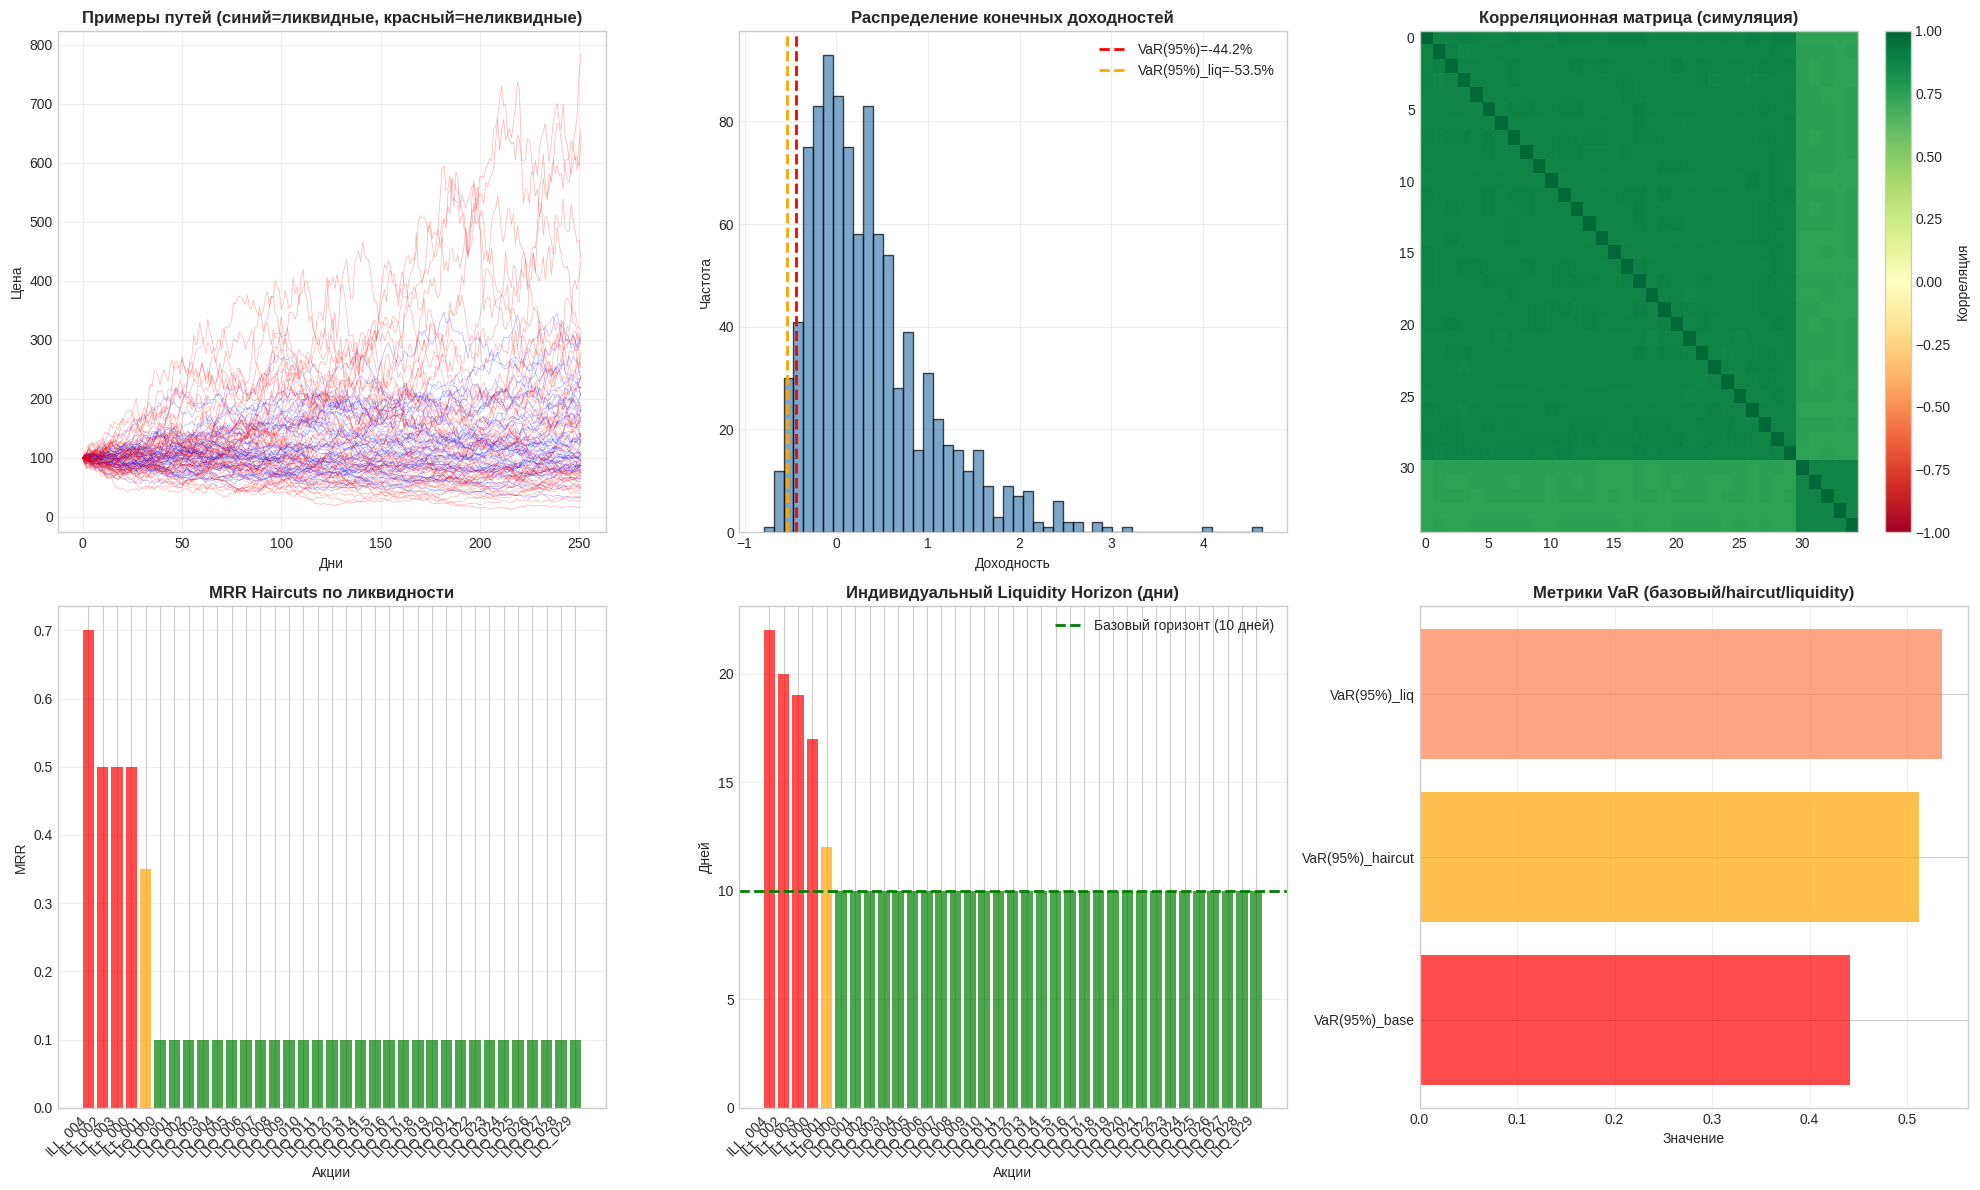

In [14]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 12))

ax1 = plt.subplot(2, 3, 1)
for i in range(min(50, N_PATHS)):
    plt.plot(simulated_paths[i, :, 0], alpha=0.3, linewidth=0.5, color='blue')
for i in range(min(50, N_PATHS)):
    plt.plot(simulated_paths[i, :, -1], alpha=0.3, linewidth=0.5, color='red')
plt.title(f'Примеры путей (синий=ликвидные, красный=неликвидные)', fontsize=12, fontweight='bold')
plt.xlabel('Дни')
plt.ylabel('Цена')
plt.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 3, 2)
plt.hist(final_returns, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
plt.axvline(var_95_base, color='red', linestyle='--', linewidth=2, label=f'VaR(95%)={var_95_base:.1%}')
plt.axvline(var_95_liquidity, color='orange', linestyle='--', linewidth=2, label=f'VaR(95%)_liq={var_95_liquidity:.1%}')
plt.title('Распределение конечных доходностей', fontsize=12, fontweight='bold')
plt.xlabel('Доходность')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)

ax3 = plt.subplot(2, 3, 3)
im = plt.imshow(sim_corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.title('Корреляционная матрица (симуляция)', fontsize=12, fontweight='bold')
plt.colorbar(im, label='Корреляция')
plt.grid(False)

ax4 = plt.subplot(2, 3, 4)
liquidity_data = [(trading_days[t], haircuts[t], liquidity_horizons[t], t) for t in tickers]
liquidity_data.sort(key=lambda x: x[0])
x = range(len(liquidity_data))
haircut_values = [d[1] for d in liquidity_data]
liquidity_values = [d[0] for d in liquidity_data]

bars = plt.bar(x, haircut_values, color=['green' if l >= 0.8 else 'orange' if l >= 0.5 else 'red' for l in liquidity_values], alpha=0.7)
plt.title('MRR Haircuts по ликвидности', fontsize=12, fontweight='bold')
plt.xlabel('Акции')
plt.ylabel('MRR')
plt.xticks(x, [d[3] for d in liquidity_data], rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

ax5 = plt.subplot(2, 3, 5)
horizon_values = [d[2] for d in liquidity_data]
plt.bar(x, horizon_values, color=['green' if l >= 0.8 else 'orange' if l >= 0.5 else 'red' for l in liquidity_values], alpha=0.7)
plt.axhline(y=10, color='green', linestyle='--', linewidth=2, label='Базовый горизонт (10 дней)')
plt.title('Индивидуальный Liquidity Horizon (дни)', fontsize=12, fontweight='bold')
plt.xlabel('Акции')
plt.ylabel('Дней')
plt.xticks(x, [d[3] for d in liquidity_data], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

ax6 = plt.subplot(2, 3, 6)
metrics = ['VaR(95%)_base', 'VaR(95%)_haircut', 'VaR(95%)_liq']
values = [var_95_base, var_95_adjusted, var_95_liquidity]
colors = ['red', 'orange', 'coral']

plt.barh(metrics, [-v for v in values], color=colors, alpha=0.7)
plt.title('Метрики VaR (базовый/haircut/liquidity)', fontsize=12, fontweight='bold')
plt.xlabel('Значение')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('illiquid_simulation_results_v4.png', dpi=150, bbox_inches='tight')
print("Визуализация сохранена в illiquid_simulation_results_v4.png")
plt.show()

## Заключение

In [15]:
print(f"""
МОДЕЛЬ ДЛЯ НЕЛИКВИДНЫХ АКЦИЙ
   • Индивидуальный liquidity horizon по акциям
       • Формула: horizon = 10 × (0.80 / trading_ratio)
       • Диапазон: 10-60 дней в зависимости от ликвидности
       • Обоснование: Чем ниже ликвидность, тем больше дней для ликвидации
   • Режим-зависимая волатильность для неликвидных
       • Использует волатильность ликвидных акций того же сектора
       • Bull/Bear волатильность калибруется отдельно
       • Обоснование: Недостаток данных для прямого GARCH на неликвидных
   • Устойчивая калибровка корреляций
       • Минимум {MIN_SECTOR_SIZE} ликвидных акций в секторе для надёжной калибровки
       • Fallback на средние значения при недостатке данных
       • Межсекторные корреляции с проверкой размера выборки
   • GARCH калибруется на ВСЕХ данных + Bull + Bear режимах
   • Индивидуальные дрейфы для каждой акции
   • VaR пересчитывается ПОСЛЕ применения haircuts
   • Обработка краевых случаев в GARCH и корреляциях

СИМУЛЯЦИЯ ЗАВЕРШЕНА
   • Путей: {N_PATHS}
   • Горизонт: {HORIZON} дней
   • simulated_paths.shape: {simulated_paths.shape}

МЕТРИКИ РИСКА
   • VaR(95%) базовый: {var_95_base:.2%}
   • VaR(95%) с haircuts: {var_95_adjusted:.2%}
   • VaR(95%) с liquidity: {var_95_liquidity:.2%}
   • VaR(99%) базовый: {var_99_base:.2%}
   • VaR(99%) с haircuts: {var_99_adjusted:.2%}
   • VaR(99%) с liquidity: {var_99_liquidity:.2%}
   • Liquidity Scaling Factor: {liquidity_scaling_factor:.3f}

СОХРАНЁННЫЕ ФАЙЛЫ
   • illiquid_simulated_paths_v4.csv
   • illiquid_path_statistics_v4.csv
   • illiquid_metrics_v4.csv
   • illiquid_simulation_results_v4.png
""")


МОДЕЛЬ ДЛЯ НЕЛИКВИДНЫХ АКЦИЙ
   • Индивидуальный liquidity horizon по акциям
       • Формула: horizon = 10 × (0.80 / trading_ratio)
       • Диапазон: 10-60 дней в зависимости от ликвидности
       • Обоснование: Чем ниже ликвидность, тем больше дней для ликвидации
   • Режим-зависимая волатильность для неликвидных
       • Использует волатильность ликвидных акций того же сектора
       • Bull/Bear волатильность калибруется отдельно
       • Обоснование: Недостаток данных для прямого GARCH на неликвидных
   • Устойчивая калибровка корреляций
       • Минимум 3 ликвидных акций в секторе для надёжной калибровки
       • Fallback на средние значения при недостатке данных
       • Межсекторные корреляции с проверкой размера выборки
   • GARCH калибруется на ВСЕХ данных + Bull + Bear режимах
   • Индивидуальные дрейфы для каждой акции
   • VaR пересчитывается ПОСЛЕ применения haircuts
   • Обработка краевых случаев в GARCH и корреляциях

СИМУЛЯЦИЯ ЗАВЕРШЕНА
   • Путей: 1000
   • Горизонт: